Точность для service_108: 0.9990400000
Точность для service_116: 0.9994400000


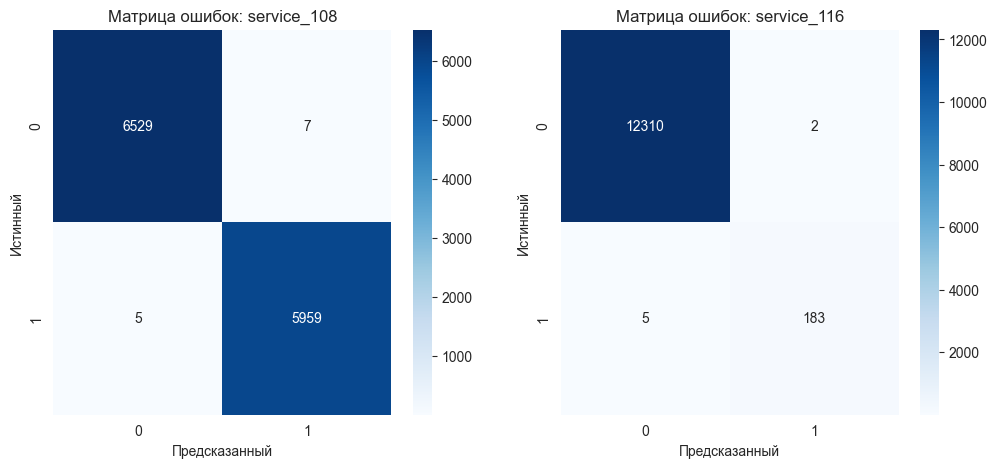

Ошибочные для 108


,age,child_number,family_size,income_childEveryMonthPosob_Oro,income_edvThirdChild,study_certificate,true_target,pred_target,prob_target
16678,6,1,4,67832.01,131842.48,0,1,0,0.467289
16826,14,2,5,84748.40,189902.82,0,1,0,0.475757
37506,15,1,2,34067.95,65346.59,0,0,1,0.546812
18662,9,1,2,33965.06,48182.37,0,0,1,0.538411
17242,11,2,4,67830.59,140007.68,0,1,0,0.462038
47068,13,1,3,50997.56,77837.97,0,0,1,0.504842
3659,12,2,3,50899.87,127809.82,0,1,0,0.475630
44722,11,2,3,51052.49,67041.36,0,0,1,0.507602
35660,15,1,3,51030.14,96173.90,0,0,1,0.509579
31363,5,4,5,84785.90,251206.57,0,1,0,0.441502


Ошибочные для 116


,age,child_number,family_size,income_childEveryMonthPosob_Oro,income_edvThirdChild,study_certificate,true_target,pred_target,prob_target
49658,1,3,5,107620.75,153718.50,0,1,0,0.459147
896,0,4,5,140107.33,154682.36,0,0,1,0.650325
44859,0,2,10,185647.83,173443.07,0,0,1,0.939918
21221,0,3,8,120641.88,244410.46,0,1,0,0.464443
27227,2,7,8,121659.79,243695.48,0,1,0,0.102166
39047,1,3,6,78167.92,185082.60,0,1,0,0.443456
48585,2,7,10,138827.79,300027.97,0,1,0,0.264880


Модель сохранена в models\servicePredictor_108_116_sklearn.onnx


In [23]:
import matplotlib.pyplot as plt
import onnx
import pandas as pd
import seaborn as sns
from IPython.display import display
from onnx import helper
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

# Загружаем данные
file_path = '../resources/dataset_108_116_with_separate_incomes.csv'
data = pd.read_csv(file_path).drop_duplicates()

# Определяем признаки и целевые переменные (услуги)
features = ["age", "child_number", "family_size", "income_childEveryMonthPosob_Oro", "income_edvThirdChild", "study_certificate"]
service_columns = ["service_108", "service_116"]

X = data[features]
y = data[service_columns]

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Масштабируем данные (нормализация 0-1)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучаем модель
mlp = MLPClassifier(max_iter=1000, alpha=0.00001, random_state=0)
mlp.fit(X_train_scaled, y_train)

# Прогнозируем
y_pred = mlp.predict(X_test_scaled)

# Получаем вероятности предсказания
y_prob = mlp.predict_proba(X_test_scaled)

# Оценка точности по каждой услуге
for i, service in enumerate(service_columns):
    acc = accuracy_score(y_test[service], y_pred[:, i])
    print(f"Точность для {service}: {acc:.10f}")

# Визуализируем матрицы ошибок
fig, axes = plt.subplots(1, len(service_columns), figsize=(6 * len(service_columns), 5))

for i, service in enumerate(service_columns):
    cm = confusion_matrix(y_test[service], y_pred[:, i])

    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", ax=axes[i])
    axes[i].set_title(f"Матрица ошибок: {service}")
    axes[i].set_xlabel("Предсказанный")
    axes[i].set_ylabel("Истинный")

plt.show()

# Ошибки для 108
print("Ошибочные для 108")
# Ошибочные индексы
wrong_idx_108 = (y_test["service_108"] != y_pred[:, 0])
errors_108 = X_test[wrong_idx_108].copy()
errors_108["true_target"] = y_test["service_108"][wrong_idx_108]
errors_108["pred_target"] = y_pred[:, 0][wrong_idx_108]
errors_108["prob_target"] = y_prob[:, 0][wrong_idx_108]
display(errors_108)

# Ошибки для 116
print("Ошибочные для 116")
# Ошибочные индексы
wrong_idx_116 = (y_test["service_116"] != y_pred[:, 1])
errors_116 = X_test[wrong_idx_116].copy()
errors_116["true_target"] = y_test["service_116"][wrong_idx_116]
errors_116["pred_target"] = y_pred[:, 1][wrong_idx_116]
errors_116["prob_target"] = y_prob[:, 1][wrong_idx_116]
display(errors_116)

# Создаём конвейер (Pipeline), объединяющий нормализатор и модель
pipeline = Pipeline([
    ("scaler", scaler),
    ("mlp", mlp)
])

# Определяем входную форму (число признаков)
input_shape = FloatTensorType([None, X_train.shape[1]])

# Конвертируем в ONNX
options = {"zipmap": False}
onnx_model = convert_sklearn(
    pipeline,
    initial_types=[("input", input_shape)],
    options={id(mlp): options}
)

# skl2onnx по умолчанию вместо "сырого выхода сигмоиды" возвращает вероятности и метки
# вернем "сырой выход сигмоиды" перед сохранением:
# 1. Получаем структуру модели
graph = onnx_model.graph
# 2. Построим карту: выход -> список узлов
output_to_node = {}
for node in graph.node:
    for input_name in node.input:
        output_to_node.setdefault(input_name, []).append(node)


# 3. Соберём всех потомков начиная с out_activations_result
def collect_all_descendants(start_name, output_to_node):
    visited = set()
    queue = [start_name]

    while queue:
        current = queue.pop()
        if current in visited:
            continue
        visited.add(current)
        for node in output_to_node.get(current, []):
            for output_name in node.output:
                queue.append(output_name)
    return visited


descendant_outputs = collect_all_descendants("out_activations_result", output_to_node)
# 4. Удалим все узлы, которые используют эти выходы
nodes_to_remove = []
for node in graph.node:
    if any(inp in descendant_outputs for inp in node.input):
        nodes_to_remove.append(node)

for node in nodes_to_remove:
    graph.node.remove(node)
# 5. Меняем выход модели
del graph.output[:]
out_info = helper.make_tensor_value_info(
    name="out_activations_result",
    elem_type=onnx.TensorProto.FLOAT,
    shape=[None, y_train.shape[1]]
)
graph.output.append(out_info)

# Сохраняем модель
onnx_path = "models\\servicePredictor_108_116_sklearn.onnx"
with open(onnx_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"Модель сохранена в {onnx_path}")

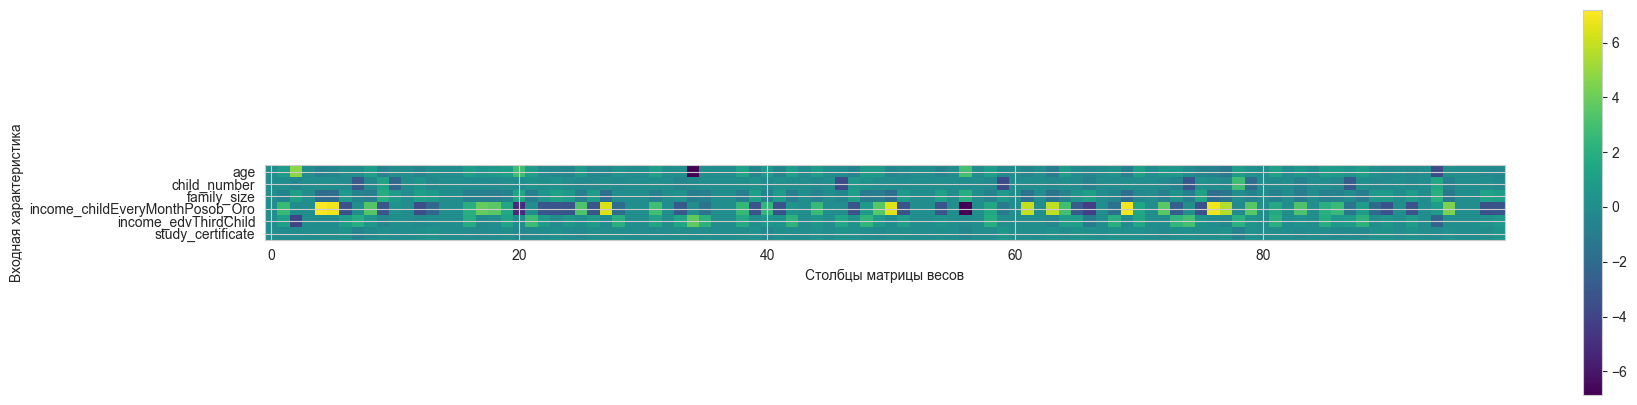

In [24]:
# веса, которые были вычислены при подключении входного слоя к первому скрытому слою.
# Строки в этом графике соответствуют 6 входным признакам, а столбцы – 100 скрытым элементам.
plt.figure(figsize=(20, 5))
plt.imshow(mlp.coefs_[0], interpolation='none', cmap='viridis')
plt.yticks(range(6), features)
plt.xlabel("Столбцы матрицы весов")
plt.ylabel("Входная характеристика")
plt.colorbar()